### Analitica de Datos — Universidad de San Andres
### Clase 01: Exploracion, Manipulacion y Visualizacion

**Otoño 2026 · Negocios Digitales**

---

### 

| # | Seccion | Temas |
|---|---|---|
| 1 | Setup | Instalacion e imports |
| 2 | Carga y primer vistazo | `read_csv`, `head`, `tail`, `shape` |
| 3 | Tipos y estadísticas | `info`, `describe`, `value_counts` |
| 4 | Calidad del dato | Nulos, duplicados, limpieza |
| 5 | Manipulacion | Filtros, columnas nuevas, ordenamiento, groupby |
| 6 | Visualizacion | Countplot, histograma, boxplot, scatter, heatmap |

###

---

**Dataset:** Startups de IA con datos reales (Crunchbase / TechCrunch / PitchBook, 2024-2025).
Empresas como OpenAI, Anthropic, xAI, DeepSeek, Mistral, Cursor, Canva, Waymo, Figure AI y mas.

| Columna | Descripcion |
|---|---|
| `startup` | Nombre de la empresa |
| `pais` | Pais de origen |
| `anio_fundacion` | Año de fundacion |
| `sector` | Categoria (LLM, Robotica, Coding AI...) |
| `ultima_ronda` | Etapa de la ultima ronda (Seed, Serie A/B/C...) |
| `monto_ronda_usd_mm` | Monto levantado en la ultima ronda (USD millones) |
| `valuacion_usd_mm` | Valuacion al momento de esa ronda (USD millones) |
| `empleados` | Cantidad de empleados |
| `inversores_clave` | Principales inversores |

###

---

### Setup y Librerias

In [1]:
!pip install pandas matplotlib seaborn --quiet

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


---
### Carga y Primer Vistazo

In [3]:
df_startups = pd.read_csv('startups.csv', index_col=0)

In [4]:
# Primeras 5 filas
df_startups.head()

,startup,pais,anio_fundacion,sector,ultima_ronda,monto_ronda_usd_mm,valuacion_usd_mm,empleados,inversores_clave
0,Weights AI,USA,2023,Plataforma ML,Seed,25.0,NaN,30,Sequoia Scout
1,Replit,USA,2016,Coding AI,Serie B,97.0,1160.0,200,"Andreessen Horowitz, Sequoia, Google"
2,Etched,USA,2022,AI Hardware / Chips,Seed,120.0,NaN,50,"Primary Venture, Y Combinator"
3,Magic AI,USA,2023,Coding AI,Serie C,320.0,NaN,100,"CapitalG, Sequoia, Jane Street"
4,Wiz,Israel,2020,Cybersecurity AI,Serie E,1000.0,12000.0,1800,"Sequoia, Andreessen Horowitz, Index Ventures"


In [5]:
# Ultimas 5 filas
df_startups.tail()

,startup,pais,anio_fundacion,sector,ultima_ronda,monto_ronda_usd_mm,valuacion_usd_mm,empleados,inversores_clave
111,Skild AI,USA,2023,Robotica,Serie A,300.0,1500.0,80,"Lightspeed, Coatue, Bezos Expeditions"
112,Duolingo,USA,2011,Edtech AI,Publica,NaN,12000.0,1000,Publica (NASDAQ: DUOL)
113,Together AI,USA,2022,Infraestructura Cloud,Serie B,305.0,3300.0,200,"Salesforce Ventures, Kleiner Perkins"
114,Synthell,USA,2022,Edtech AI,Seed,5.0,NaN,20,Y Combinator
115,Isomorphic Labs,UK,2021,Biotech AI,Serie A,600.0,3000.0,200,"Alphabet, Foresite Capital"


In [6]:
# (filas, columnas)
print(f"El dataset contiene {df_startups.shape[0]} filas y {df_startups.shape[1]} columnas")

El dataset contiene 116 filas y 9 columnas


In [7]:
# Nombres de las columnas
df_startups.columns.tolist()

['startup',
 'pais',
 'anio_fundacion',
 'sector',
 'ultima_ronda',
 'monto_ronda_usd_mm',
 'valuacion_usd_mm',
 'empleados',
 'inversores_clave']

---
### Tipos de dato y estadísticas

In [8]:
# Tipo de dato de cada columna + cuantos valores no son nulos
df_startups.info()

<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   startup             116 non-null    str    
 1   pais                116 non-null    str    
 2   anio_fundacion      116 non-null    int64  
 3   sector              116 non-null    str    
 4   ultima_ronda        116 non-null    str    
 5   monto_ronda_usd_mm  104 non-null    float64
 6   valuacion_usd_mm    85 non-null     float64
 7   empleados           116 non-null    int64  
 8   inversores_clave    116 non-null    str    
dtypes: float64(2), int64(2), str(5)
memory usage: 15.6 KB


In [9]:
# Estadisticas descriptivas de columnas numericas
df_startups.describe().round(2)

,anio_fundacion,monto_ronda_usd_mm,valuacion_usd_mm,empleados
count,116.00,104.00,85.00,116.00
mean,2018.89,740.41,14743.85,654.21
std,3.92,1555.39,46246.84,1004.31
min,2008.00,3.00,200.00,15.00
25%,2016.00,100.00,1250.00,150.00
50%,2019.00,231.00,3000.00,250.00
75%,2022.00,648.75,10000.00,625.00
max,2024.00,10000.00,300000.00,6000.00


`monto_ronda_usd_mm`: media ~USD 740M vs mediana ~USD 231M. Pocas mega-rondas (OpenAI 6.600M, xAI 6.000M, Databricks 10.000M) jalan el promedio hacia arriba. La mediana es el numero honesto.

`valuacion_usd_mm`: media ~USD 14.700M vs mediana ~USD 3.000M — OpenAI (USD 300.000M) es un outlier enorme que distorsiona completamente el promedio.

`empleados`: media 654 vs mediana 250 — mismo patron. Databricks (6.000) y Waymo (4.000) jalan la media.

In [10]:
# Comparar media vs mediana para ver el sesgo
cols = ['monto_ronda_usd_mm', 'valuacion_usd_mm', 'empleados']

for col in cols:
    media   = df_startups[col].mean()
    mediana = df_startups[col].median()
    ratio   = media / mediana
    print(f"{col}")
    print(f"  Media:   {media:>10,.0f}")
    print(f"  Mediana: {mediana:>10,.0f}")
    print(f"  Ratio:   {ratio:>10.1f}x  <- cuanto mas alto, mas sesgado")
    print()

monto_ronda_usd_mm
  Media:          740
  Mediana:        231
  Ratio:          3.2x  <- cuanto mas alto, mas sesgado

valuacion_usd_mm
  Media:       14,744
  Mediana:      3,000
  Ratio:          4.9x  <- cuanto mas alto, mas sesgado

empleados
  Media:          654
  Mediana:        250
  Ratio:          2.6x  <- cuanto mas alto, mas sesgado



In [11]:
# Los 3 mayores de cada columna — los culpables del sesgo
for col in cols:
    print(f"Top 3 por {col}:")
    print(df_startups.nlargest(3, col)[['startup', col]].to_string(index=False))
    print()

Top 3 por monto_ronda_usd_mm:
   startup  monto_ronda_usd_mm
Databricks             10000.0
    OpenAI              6600.0
    OpenAI              6600.0

Top 3 por valuacion_usd_mm:
   startup  valuacion_usd_mm
    OpenAI          300000.0
    OpenAI          300000.0
Databricks           62000.0

Top 3 por empleados:
   startup  empleados
Databricks       6000
     Canva       4500
     Waymo       4000



In [12]:
# Cuantas veces aparece cada valor — ordenado de mayor a menor
df_startups['startup'].value_counts()

startup
Weights AI         2
Apptronik          2
Darktrace          2
DeepSeek           2
World Labs         2
                  ..
Cerebras           1
Skild AI           1
Together AI        1
Synthell           1
Isomorphic Labs    1
Name: count, Length: 101, dtype: int64

In [13]:
# Cuantos valores distintos hay — devuelve un numero
df_startups['startup'].nunique()

101

In [16]:
# Cuales son los valores distintos — devuelve la lista
df_startups['startup'].unique()

<ArrowStringArray>
[     'Weights AI',          'Replit',          'Etched',        'Magic AI',
             'Wiz',          'Qdrant',   'Perplexity AI',         'Tabnine',
       'Apptronik',       'Darktrace',
 ...
          'Alifyz',         'Vast AI',       'Runway ML',          'Mercor',
          'PathAI',        'Cerebras',        'Skild AI',     'Together AI',
        'Synthell', 'Isomorphic Labs']
Length: 101, dtype: str

---
### Calidad del dato 

In [17]:
# Cuantos nulos hay por columna
df_startups.isnull().sum()

startup                0
pais                   0
anio_fundacion         0
sector                 0
ultima_ronda           0
monto_ronda_usd_mm    12
valuacion_usd_mm      31
empleados              0
inversores_clave       0
dtype: int64

In [18]:
# Lo mismo pero en porcentaje
(df_startups.isnull().sum() / len(df_startups) * 100).round(1)

startup                0.0
pais                   0.0
anio_fundacion         0.0
sector                 0.0
ultima_ronda           0.0
monto_ronda_usd_mm    10.3
valuacion_usd_mm      26.7
empleados              0.0
inversores_clave       0.0
dtype: float64

In [19]:
# Tabla de nulos: cantidad y porcentaje
nulos = df_startups.isnull().sum()
porcentaje = (nulos / len(df_startups) * 100).round(1)

tabla_nulos = pd.DataFrame({
    'nulos': nulos,
    '%': porcentaje
})

tabla_nulos[tabla_nulos['nulos'] > 0].sort_values('nulos', ascending=False)

,nulos,%
valuacion_usd_mm,31,26.7
monto_ronda_usd_mm,12,10.3



`valuacion_usd_mm` (~27%): DeepSeek es autofinanciada, algunas startups no divulgan valuacion publica.
`monto_ronda_usd_mm` (~10%): Midjourney nunca levanto ronda externa, empresas publicas no reportan monto reciente.

Estos nulos son **datos faltantes reales**, no errores del dataset. Seaborn los ignora automaticamente en los graficos.

In [25]:
# Ver filas que tienen nulo en valuacion
df_startups[df_startups['valuacion_usd_mm'].isnull()][['startup', 'pais', 'sector', 'ultima_ronda','valuacion_usd_mm']].head()

,startup,pais,sector,ultima_ronda,valuacion_usd_mm
0,Weights AI,USA,Plataforma ML,Seed,NaN
2,Etched,USA,AI Hardware / Chips,Seed,NaN
3,Magic AI,USA,Coding AI,Serie C,NaN
5,Qdrant,Alemania,Plataforma ML,Serie B,NaN
7,Tabnine,Israel,Coding AI,Serie C,NaN


In [21]:
# Cuantas filas duplicadas hay
df_startups.duplicated().sum()

15

In [26]:
# Ver los duplicados (keep=False muestra TODAS las ocurrencias)
df_startups[df_startups.duplicated(keep=False)].sort_values('startup').head()

,startup,pais,anio_fundacion,sector,ultima_ronda,monto_ronda_usd_mm,valuacion_usd_mm,empleados,inversores_clave
36,1X Technologies,Noruega,2014,Robotica,Serie B,100.0,NaN,200,"OpenAI, EQT Ventures"
65,1X Technologies,Noruega,2014,Robotica,Serie B,100.0,NaN,200,"OpenAI, EQT Ventures"
8,Apptronik,USA,2016,Robotica,Serie A,350.0,NaN,250,"Google, Capital Factory"
48,Apptronik,USA,2016,Robotica,Serie A,350.0,NaN,250,"Google, Capital Factory"
83,Covariant,USA,2017,Robotica,Serie C,222.0,2000.0,200,"Index Ventures, Tiger Global"


In [27]:
# Eliminar duplicados — conservar la primera ocurrencia
df_clean = df_startups.drop_duplicates(keep='first').reset_index(drop=True)

print(f"Antes : {len(df_startups)} filas")
print(f"Despues: {len(df_clean)} filas")

Antes : 116 filas
Despues: 101 filas


`keep='first'` conserva la primera ocurrencia de cada fila duplicada y elimina las siguientes.
`reset_index(drop=True)` reinicia el indice desde 0 para que quede limpio.

A partir de aca trabajamos siempre con `df_clean`.

---
### Manipulacion

#### Seleccionar Columnas y Filas

In [28]:
# Seleccionar Columnas y Filas
df_clean['startup'].head(10)

0       Weights AI
1           Replit
2           Etched
3         Magic AI
4              Wiz
5           Qdrant
6    Perplexity AI
7          Tabnine
8        Apptronik
9        Darktrace
Name: startup, dtype: str

In [29]:
# Seleccionar multiples columnas
df_clean[['startup', 'sector', 'valuacion_usd_mm']].head(10)

,startup,sector,valuacion_usd_mm
0,Weights AI,Plataforma ML,NaN
1,Replit,Coding AI,1160.0
2,Etched,AI Hardware / Chips,NaN
3,Magic AI,Coding AI,NaN
4,Wiz,Cybersecurity AI,12000.0
5,Qdrant,Plataforma ML,NaN
6,Perplexity AI,Busqueda / Agentes,9000.0
7,Tabnine,Coding AI,NaN
8,Apptronik,Robotica,NaN
9,Darktrace,Cybersecurity AI,2500.0


In [30]:
# Filtrar filas: solo startups de USA
df_usa = df_clean[df_clean['pais'] == 'USA']
print(f"Startups de USA: {len(df_usa)}")
df_usa[['startup', 'sector', 'valuacion_usd_mm']].head(8)

Startups de USA: 72


,startup,sector,valuacion_usd_mm
0,Weights AI,Plataforma ML,NaN
1,Replit,Coding AI,1160.0
2,Etched,AI Hardware / Chips,NaN
3,Magic AI,Coding AI,NaN
6,Perplexity AI,Busqueda / Agentes,9000.0
8,Apptronik,Robotica,NaN
11,Spring Health,Healthtech AI,7500.0
13,Hebbia,Enterprise Search,700.0


In [31]:
# Filtrar con condicion numerica: valuacion mayor a USD 10.000M
df_clean[df_clean['valuacion_usd_mm'] > 10000][['startup', 'pais', 'valuacion_usd_mm']].sort_values('valuacion_usd_mm', ascending=False)

,startup,pais,valuacion_usd_mm
85,OpenAI,USA,300000.0
83,Databricks,USA,62000.0
64,Anthropic,USA,60000.0
36,xAI,USA,50000.0
90,Waymo,USA,45000.0
50,Canva,Australia,42000.0
82,Cursor / Anysphere,USA,29300.0
56,Samsara,USA,20000.0
76,CoreWeave,USA,19000.0
77,Tempus AI,USA,16000.0


In [32]:
# Condicion multiple: USA + valuacion conocida
df_clean[(df_clean['pais'] == 'USA') & (df_clean['valuacion_usd_mm'].notna())][['startup', 'sector', 'valuacion_usd_mm']].head(8)

,startup,sector,valuacion_usd_mm
1,Replit,Coding AI,1160.0
6,Perplexity AI,Busqueda / Agentes,9000.0
11,Spring Health,Healthtech AI,7500.0
13,Hebbia,Enterprise Search,700.0
15,World Labs,LLM / Foundation Models,1000.0
16,Physical Intelligence,Robotica,2000.0
18,Writer,Enterprise AI,1900.0
19,Nuro,Vehiculos Autonomos,8600.0


| Método | Devuelve True cuando... | Uso típico |
|---|---|---|
| `.isnull()` | el valor **es** nulo | encontrar filas con datos faltantes |
| `.notna()` | el valor **no es** nulo | filtrar filas con datos completos |

`&` = AND, `|` = OR. Cada condicion debe ir entre parentesis cuando se combinan.
`.notna()` = lo opuesto a `.isnull()` — selecciona filas donde el valor existe.

| Operador | Nombre | Devuelve True cuando... | Ejemplo |
|---|---|---|---|
| `&` | AND | las DOS condiciones son True | `(df['pais'] == 'USA') & (df['valuacion'] > 1000)` |
| `\|` | OR | AL MENOS UNA condición es True | `(df['pais'] == 'USA') \| (df['pais'] == 'UK')` |

In [37]:
# Filtrar con lista de valores — isin()
paises_top = ['USA', 'UK', 'Israel', 'China', 'Canada']
df_clean[df_clean['pais'].isin(paises_top)][['startup', 'pais', 'sector']]

,startup,pais,sector
0,Weights AI,USA,Plataforma ML
1,Replit,USA,Coding AI
2,Etched,USA,AI Hardware / Chips
3,Magic AI,USA,Coding AI
4,Wiz,Israel,Cybersecurity AI
...,...,...,...
96,Cerebras,USA,AI Hardware / Chips
97,Skild AI,USA,Robotica
98,Together AI,USA,Infraestructura Cloud
99,Synthell,USA,Edtech AI


#### Ordenar

In [49]:
# Top 10 startups por valuacion
df_clean.sort_values('valuacion_usd_mm', ascending=False).head(10)[['startup', 'pais', 'sector', 'valuacion_usd_mm']]

,startup,pais,sector,valuacion_usd_mm
85,OpenAI,USA,LLM / Foundation Models,300000.0
83,Databricks,USA,Data & Analytics,62000.0
64,Anthropic,USA,LLM / Foundation Models,60000.0
36,xAI,USA,LLM / Foundation Models,50000.0
90,Waymo,USA,Vehiculos Autonomos,45000.0
50,Canva,Australia,Diseño / Productividad,42000.0
82,Cursor / Anysphere,USA,Coding AI,29300.0
56,Samsara,USA,Data & Analytics,20000.0
76,CoreWeave,USA,Infraestructura Cloud,19000.0
77,Tempus AI,USA,Healthtech AI,16000.0


In [50]:
# Top 10 por empleados
df_clean.sort_values('empleados', ascending=False).head(10)[['startup', 'sector', 'empleados', 'valuacion_usd_mm']]

,startup,sector,empleados,valuacion_usd_mm
83,Databricks,Data & Analytics,6000,62000.0
50,Canva,Diseño / Productividad,4500,42000.0
90,Waymo,Vehiculos Autonomos,4000,45000.0
56,Samsara,Data & Analytics,3200,20000.0
88,Anduril,Defensa / Robotica,3000,14000.0
85,OpenAI,LLM / Foundation Models,3000,300000.0
80,SentinelOne,Cybersecurity AI,2800,10000.0
77,Tempus AI,Healthtech AI,2400,16000.0
9,Darktrace,Cybersecurity AI,2400,2500.0
4,Wiz,Cybersecurity AI,1800,12000.0


#### Crear Columnas Nuevas

In [38]:
# Edad de la startup al dia de hoy
df_clean['edad_anios'] = 2025 - df_clean['anio_fundacion']
df_clean[['startup', 'anio_fundacion', 'edad_anios']].head(8)

,startup,anio_fundacion,edad_anios
0,Weights AI,2023,2
1,Replit,2016,9
2,Etched,2022,3
3,Magic AI,2023,2
4,Wiz,2020,5
5,Qdrant,2021,4
6,Perplexity AI,2022,3
7,Tabnine,2018,7


In [40]:
# Una startup es "unicornio" si su valuacion supera USD 1.000 millones
df_clean['es_unicornio'] = df_clean['valuacion_usd_mm'] > 1000

df_clean[['startup', 'valuacion_usd_mm', 'es_unicornio']].head(10)

,startup,valuacion_usd_mm,es_unicornio
0,Weights AI,NaN,False
1,Replit,1160.0,True
2,Etched,NaN,False
3,Magic AI,NaN,False
4,Wiz,12000.0,True
5,Qdrant,NaN,False
6,Perplexity AI,9000.0,True
7,Tabnine,NaN,False
8,Apptronik,NaN,False
9,Darktrace,2500.0,True


In [41]:
# Cuantos unicornios hay en el dataset?
df_clean['es_unicornio'].value_counts()

es_unicornio
True     57
False    44
Name: count, dtype: int64

#### Grouby - resumir por grupos

In [43]:
# Promedio de valuacion por sector
df_clean.groupby('sector')['valuacion_usd_mm'].mean().round(1).sort_values(ascending=False).reset_index(drop=False).rename(columns={'valuacion_usd_mm': 'valuacion_promedio_usd_mm'})

,sector,valuacion_promedio_usd_mm
0,LLM / Foundation Models,33346.4
1,Data & Analytics,32000.0
2,Diseño / Productividad,22666.7
3,Vehiculos Autonomos,19533.3
4,Defensa / Robotica,14000.0
5,Busqueda / Agentes,9000.0
6,Coding AI,8577.4
7,Infraestructura Cloud,7933.3
8,Edtech AI,6500.0
9,Cybersecurity AI,6280.0


In [44]:
# Resumen completo por sector
resumen_sector = df_clean.groupby('sector').agg(
    cantidad     = ('startup',         'count'),
    valuacion_md = ('valuacion_usd_mm', 'median'),
    monto_md     = ('monto_ronda_usd_mm','median'),
    empleados_md = ('empleados',        'median'),
).round(1).sort_values('cantidad', ascending=False)

resumen_sector

,cantidad,valuacion_md,monto_md,empleados_md
sector,,,,
LLM / Foundation Models,18,5250.0,850.0,200.0
Robotica,7,2000.0,300.0,200.0
Plataforma ML,7,750.0,50.0,200.0
Coding AI,7,1250.0,227.0,200.0
Healthtech AI,6,1640.0,110.0,250.0
Imagen / Generativa,6,1000.0,90.0,150.0
Biotech AI,5,2000.0,382.5,300.0
Cybersecurity AI,5,5100.0,550.0,1800.0
Infraestructura Cloud,5,3300.0,305.0,200.0


In [48]:
# Cuantas startups hay por pais
tabla = (df_clean.groupby('pais')['startup']
         .count()
         .sort_values(ascending=False)
         .reset_index()
         .rename(columns={'startup': 'cantidad'}))

tabla

,pais,cantidad
0,USA,72
1,Israel,6
2,China,5
3,UK,5
4,Canada,3
5,Australia,2
6,Francia,2
7,Alemania,1
8,Hong Kong,1
9,Japon,1


In [47]:
# Resumen por etapa de ronda
df_clean.groupby('ultima_ronda').agg(
    cantidad     = ('startup',          'count'),
    valuacion_md = ('valuacion_usd_mm',  'median'),
    monto_md     = ('monto_ronda_usd_mm','median'),
).round(1)

,cantidad,valuacion_md,monto_md
ultima_ronda,,,
Publica,7,12000.0,NaN
Seed,9,6500.0,65.0
Serie A,17,1500.0,250.0
Serie B,21,1160.0,130.0
Serie C,23,1850.0,222.0
Serie D,14,5100.0,285.0
Serie E,5,12000.0,1000.0
Serie F,3,14000.0,1000.0
Serie J,1,62000.0,10000.0


`groupby` + `agg` es una de las combinaciones mas poderosas de pandas.
`count` = cuantos hay · `mean` = promedio · `median` = mediana · `max` = maximo · `min` = minimo

La mediana es mas robusta que la media cuando hay outliers — que es exactamente el caso de valuaciones de startups.

---
## Visualizacion

> Antes de cada grafico: **¿qué pregunta de negocio estoy respondiendo?**

| Pregunta | Gráfico |
|---|---|
| ¿Cuántos hay por categoría? | `countplot` |
| ¿Cómo se distribuye una variable numérica? | `histplot` |
| ¿Cómo varía la distribución entre grupos? | `boxplot` |
| ¿Se relacionan dos variables numéricas? | `scatterplot` / `lmplot` |
| ¿Qué variables se mueven juntas? | `heatmap` |

### Countplot — ¿cuántos hay por categoría?

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_99920/223687093.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='sector', order=orden, palette='tab20')


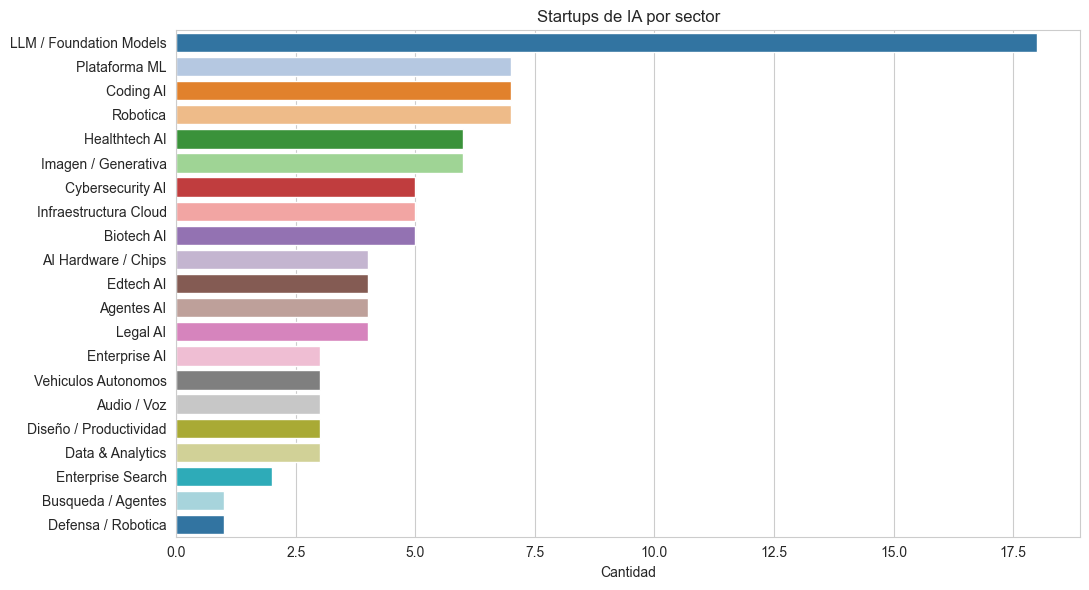

In [51]:
# Startups por sector
orden = df_clean['sector'].value_counts().index

plt.figure(figsize=(11, 6))
sns.countplot(data=df_clean, y='sector', order=orden, palette='tab20')
plt.title('Startups de IA por sector')
plt.xlabel('Cantidad')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [54]:
df_clean['sector'].value_counts(normalize=True).round(2) * 100

sector
LLM / Foundation Models    18.0
Plataforma ML               7.0
Coding AI                   7.0
Robotica                    7.0
Healthtech AI               6.0
Imagen / Generativa         6.0
Cybersecurity AI            5.0
Infraestructura Cloud       5.0
Biotech AI                  5.0
AI Hardware / Chips         4.0
Edtech AI                   4.0
Agentes AI                  4.0
Legal AI                    4.0
Enterprise AI               3.0
Vehiculos Autonomos         3.0
Audio / Voz                 3.0
Diseño / Productividad      3.0
Data & Analytics            3.0
Enterprise Search           2.0
Busqueda / Agentes          1.0
Defensa / Robotica          1.0
Name: proportion, dtype: float64

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_99920/3687726771.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean[df_clean['pais'].isin(orden_paises)],


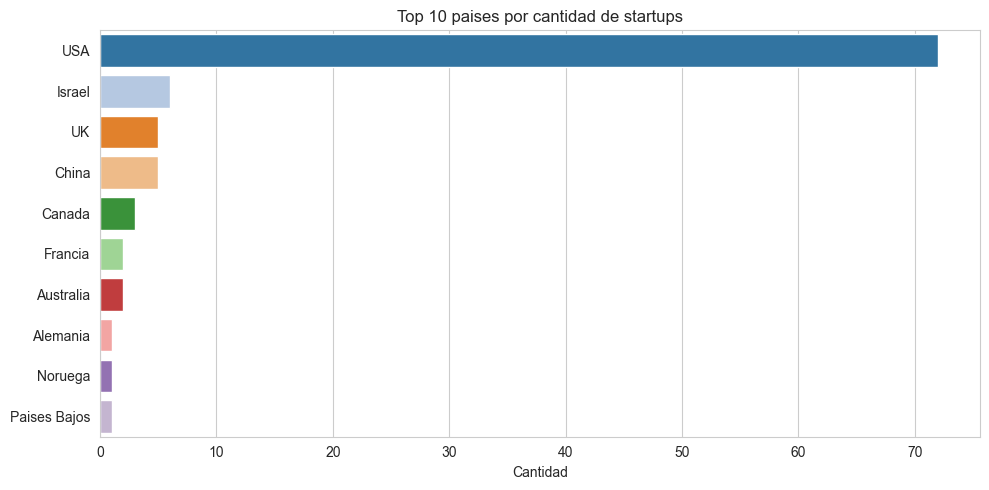

In [52]:
# Startups por pais — top 10
orden_paises = df_clean['pais'].value_counts().head(10).index

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean[df_clean['pais'].isin(orden_paises)],
              y='pais', order=orden_paises, palette='tab20')
plt.title('Top 10 paises por cantidad de startups')
plt.xlabel('Cantidad')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
df_clean['pais'].value_counts(normalize=True).round(2) * 100

pais
USA             71.0
Israel           6.0
UK               5.0
China            5.0
Canada           3.0
Francia          2.0
Australia        2.0
Alemania         1.0
Noruega          1.0
Paises Bajos     1.0
Hong Kong        1.0
Suecia           1.0
Japon            1.0
Name: proportion, dtype: float64

USA domina con el 71% del dataset. Israel, UK y China son los siguientes con 6%, 5% y 5% respectivamente.

`order=` fuerza el orden de mayor a menor — sin eso seaborn lo muestra en orden alfabético.

### Histograma — ¿cómo se distribuye una variable?

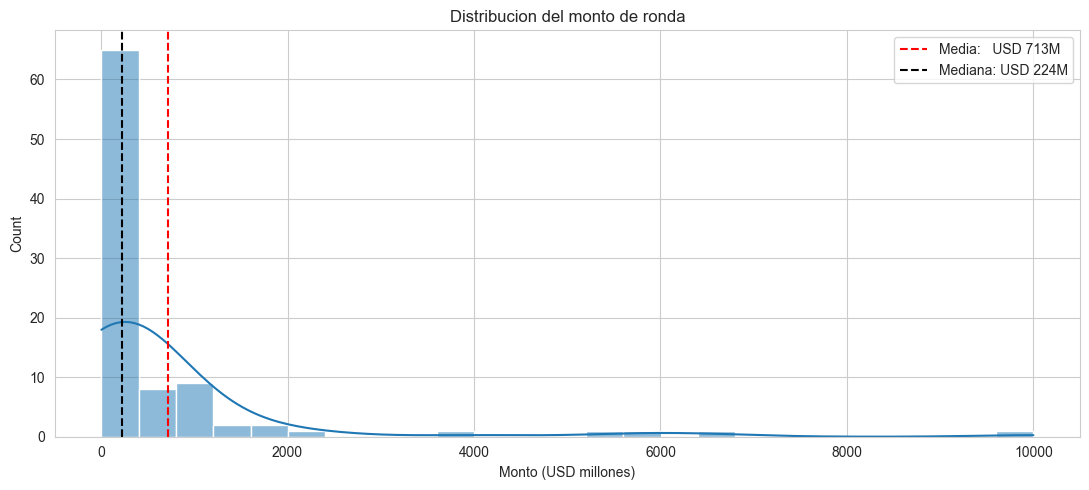

In [58]:
# Distribucion del monto de ronda
media   = df_clean['monto_ronda_usd_mm'].mean()
mediana = df_clean['monto_ronda_usd_mm'].median()

plt.figure(figsize=(11, 5))
sns.histplot(data=df_clean, x='monto_ronda_usd_mm', bins=25, kde=True)
plt.axvline(media,   color='red',   linestyle='--', label=f'Media:   USD {media:,.0f}M')
plt.axvline(mediana, color='black', linestyle='--', label=f'Mediana: USD {mediana:,.0f}M')
plt.title('Distribucion del monto de ronda')
plt.xlabel('Monto (USD millones)')
plt.legend()
plt.tight_layout()
plt.show()

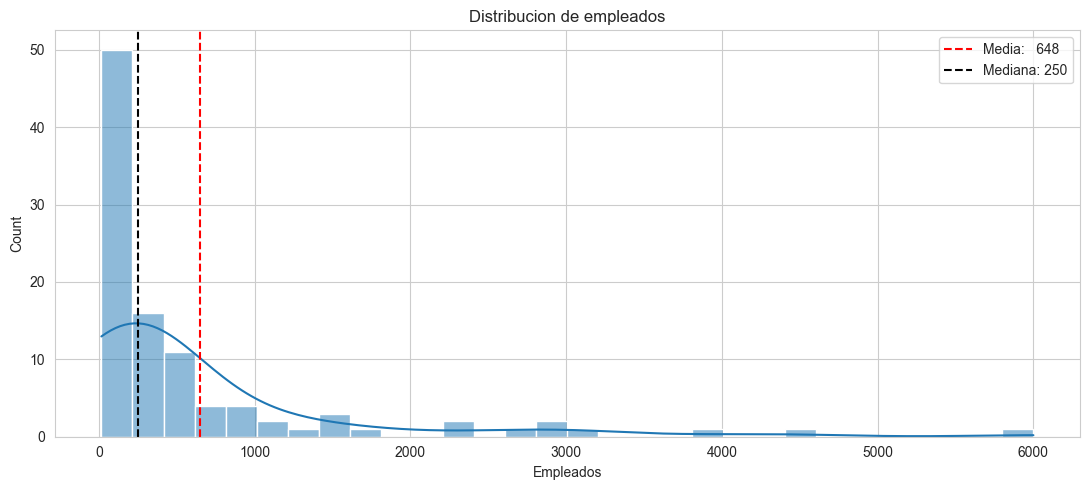

In [59]:
# Distribucion de empleados
media_emp   = df_clean['empleados'].mean()
mediana_emp = df_clean['empleados'].median()

plt.figure(figsize=(11, 5))
sns.histplot(data=df_clean, x='empleados', bins=30, kde=True)
plt.axvline(media_emp,   color='red',   linestyle='--', label=f'Media:   {media_emp:,.0f}')
plt.axvline(mediana_emp, color='black', linestyle='--', label=f'Mediana: {mediana_emp:,.0f}')
plt.title('Distribucion de empleados')
plt.xlabel('Empleados')
plt.legend()
plt.tight_layout()
plt.show()

Ambas distribuciones tienen sesgo a la derecha — la mayoría de startups son pequeñas pero unos pocos gigantes estiran la cola.

`kde=True` dibuja la curva de densidad suavizada sobre el histograma.
`axvline` dibuja una línea vertical — útil para marcar media y mediana.

### Boxplot — ¿cómo varía la distribución entre grupos?

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_99920/1714274598.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='ultima_ronda', y='valuacion_usd_mm',


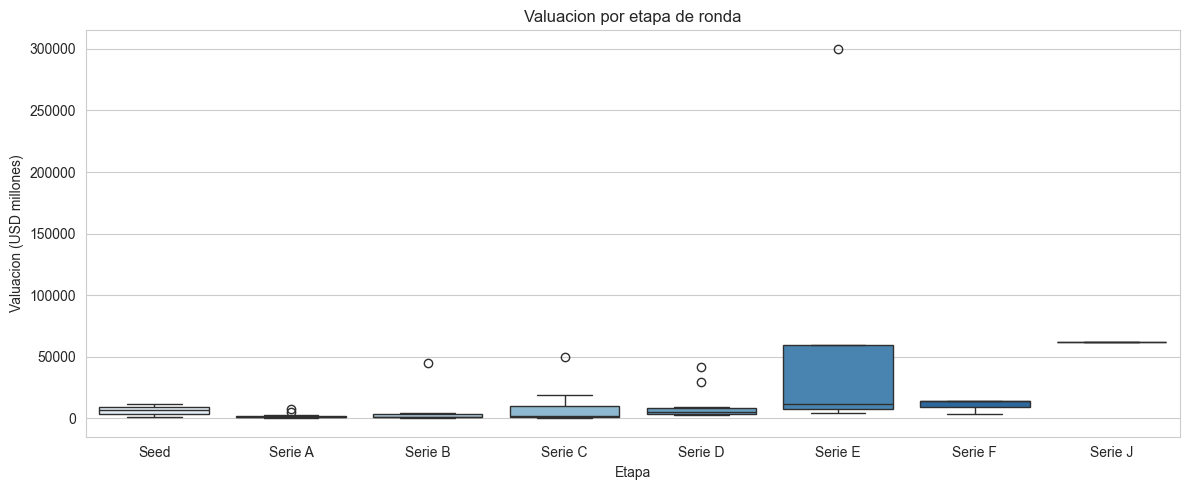

In [60]:
# Valuacion por etapa de ronda
orden_rondas = ['Seed', 'Serie A', 'Serie B', 'Serie C', 'Serie D', 'Serie E', 'Serie F', 'Serie J']

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean, x='ultima_ronda', y='valuacion_usd_mm',
            order=orden_rondas, palette='Blues')
plt.title('Valuacion por etapa de ronda')
plt.xlabel('Etapa')
plt.ylabel('Valuacion (USD millones)')
plt.tight_layout()
plt.show()

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_99920/2298229761.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['sector'].isin(top_sectores)],


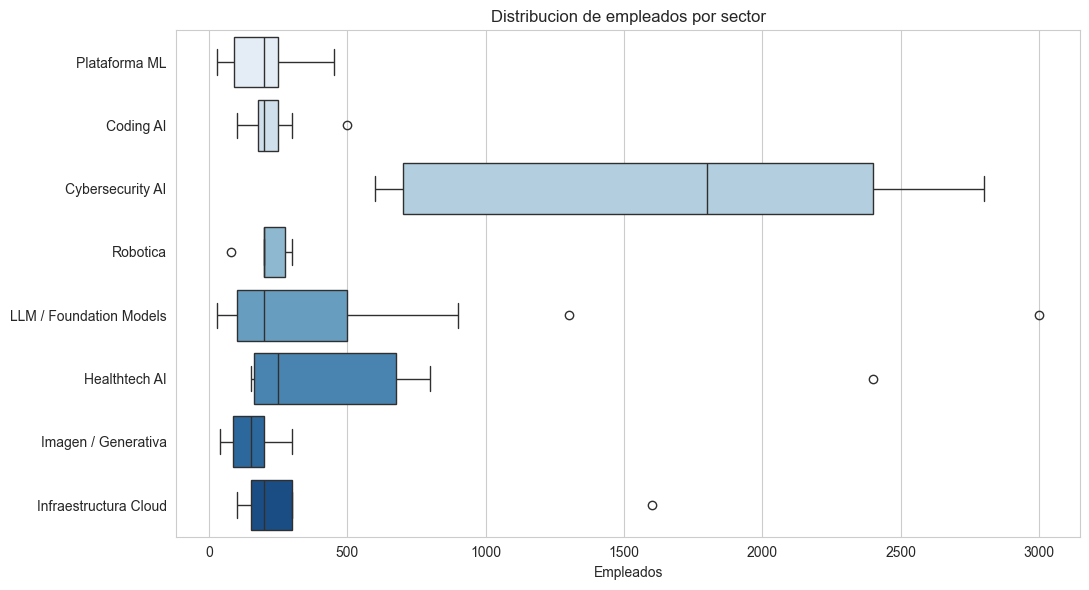

In [61]:
# Empleados por sector — top 8
top_sectores = df_clean['sector'].value_counts().head(8).index

plt.figure(figsize=(11, 6))
sns.boxplot(data=df_clean[df_clean['sector'].isin(top_sectores)],
            x='empleados', y='sector', palette='Blues')
plt.title('Distribucion de empleados por sector')
plt.xlabel('Empleados')
plt.ylabel('')
plt.tight_layout()
plt.show()

El boxplot muestra mediana, cuartiles, rango y outliers de un vistazo. Un barplot del promedio ocultaría toda esa información.

Los puntos sueltos fuera de los bigotes son outliers — por ejemplo OpenAI en Serie E.

### Scatter — ¿se relacionan dos variables numéricas?

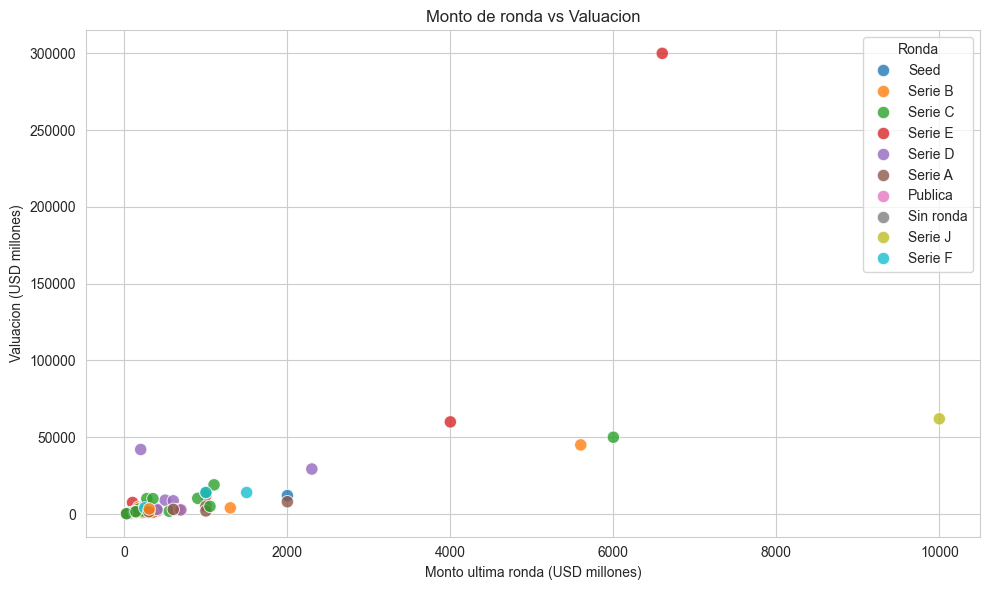

In [62]:
# Monto de ronda vs valuacion
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='monto_ronda_usd_mm', y='valuacion_usd_mm',
                hue='ultima_ronda', palette='tab10', s=80, alpha=0.8)
plt.title('Monto de ronda vs Valuacion')
plt.xlabel('Monto ultima ronda (USD millones)')
plt.ylabel('Valuacion (USD millones)')
plt.legend(title='Ronda')
plt.tight_layout()
plt.show()

El punto rojo aislado arriba es OpenAI (Serie E) — USD 6.600M de ronda y USD 300.000M de valuacion. Distorsiona completamente la escala del grafico.

El punto amarillo a la derecha es Databricks (Serie J) — la ronda mas grande del dataset (USD 10.000M) pero valuacion mucho menor que OpenAI.

El 90% de las startups se concentra abajo a la izquierda — menos de USD 2.000M de ronda y menos de USD 20.000M de valuacion.

Tendencia general — a mayor monto de ronda, mayor valuación, pero la relación no es perfecta. Hay empresas que levantaron poco y valen mucho (eficiencia de capital) y viceversa.

¿que pasa si sacamos a OpenAI? ¿Se ve mejor la tendencia del resto?

In [66]:
df_clean[['startup', 'ultima_ronda', 'monto_ronda_usd_mm', 'valuacion_usd_mm']].dropna().sort_values('valuacion_usd_mm', ascending=False).head(15)

,startup,ultima_ronda,monto_ronda_usd_mm,valuacion_usd_mm
85,OpenAI,Serie E,6600.0,300000.0
83,Databricks,Serie J,10000.0,62000.0
64,Anthropic,Serie E,4000.0,60000.0
36,xAI,Serie C,6000.0,50000.0
90,Waymo,Serie B,5600.0,45000.0
50,Canva,Serie D,200.0,42000.0
82,Cursor / Anysphere,Serie D,2300.0,29300.0
76,CoreWeave,Serie C,1100.0,19000.0
48,Mistral AI,Serie C,1000.0,14000.0
86,Scale AI,Serie F,1000.0,14000.0


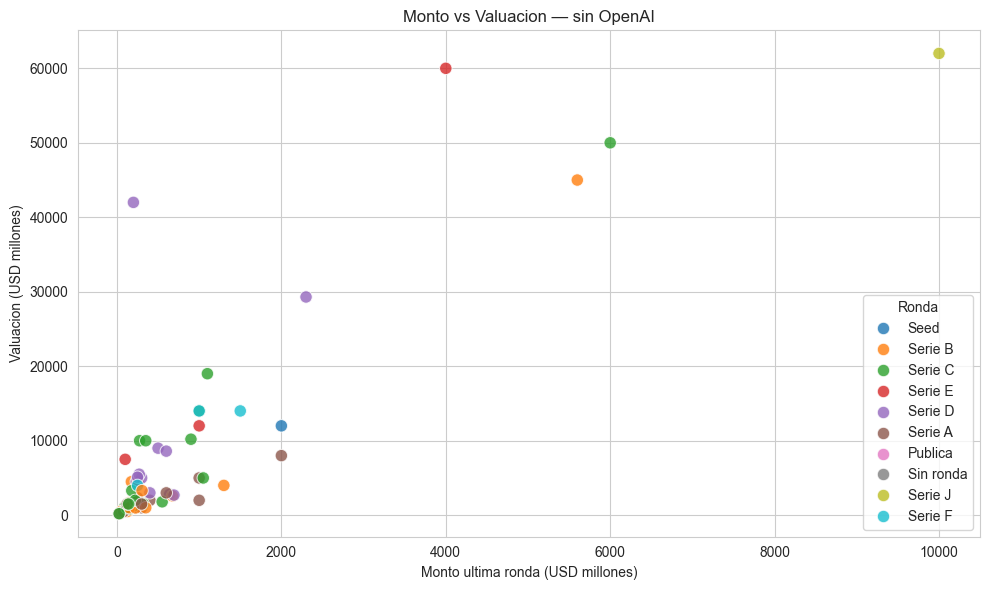

In [64]:
sin_openai = df_clean[df_clean['startup'] != 'OpenAI']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sin_openai, x='monto_ronda_usd_mm', y='valuacion_usd_mm',
                hue='ultima_ronda', palette='tab10', s=80, alpha=0.8)
plt.title('Monto vs Valuacion — sin OpenAI')
plt.xlabel('Monto ultima ronda (USD millones)')
plt.ylabel('Valuacion (USD millones)')
plt.legend(title='Ronda')
plt.tight_layout()
plt.show()

Sin OpenAI la escala baja de 300.000M a 65.000M y se ve la estructura real del mercado.

Los puntos mas altos son Anthropic (Serie E, USD 60.000M) y Databricks (Serie J, USD 62.000M).
xAI aparece en Serie C con USD 50.000M — alta valuacion para una etapa relativamente temprana.

Caso interesante: Canva (Serie D) levanto solo USD 200M pero vale USD 42.000M — señal de eficiencia de capital.
Caso opuesto: Waymo (Serie B) levanto USD 5.600M y vale USD 45.000M — requirio mucho capital para llegar ahi.

Conclusion: un solo outlier (OpenAI) distorsionaba completamente la lectura. Esto pasa todo el tiempo con datos reales.

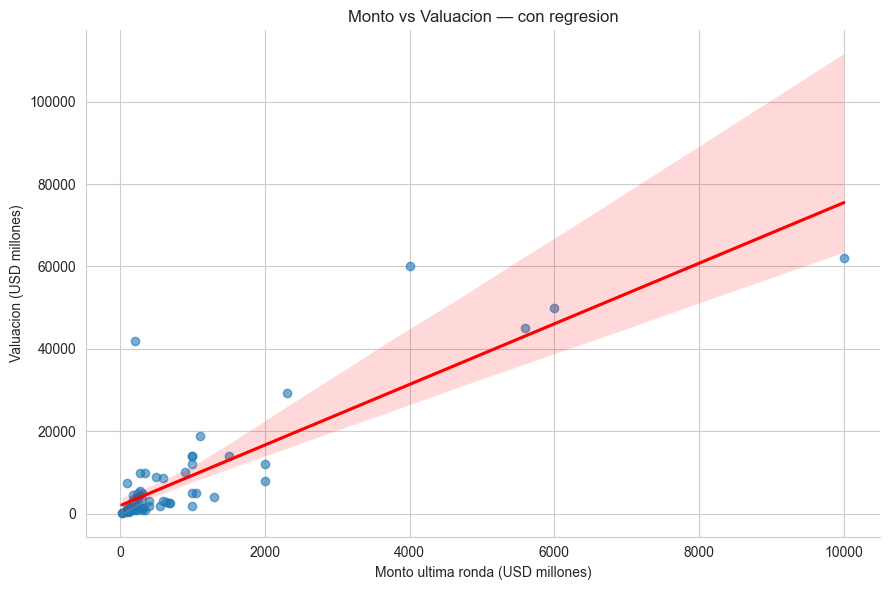

In [68]:
# Con linea de regresion — lmplot
sns.lmplot(data=sin_openai, x='monto_ronda_usd_mm', y='valuacion_usd_mm',
           height=6, aspect=1.5,
           scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.title('Monto vs Valuacion — con regresion')
plt.xlabel('Monto ultima ronda (USD millones)')
plt.ylabel('Valuacion (USD millones)')
plt.tight_layout()
plt.show()

`scatterplot` = puntos solos. `lmplot` = puntos + línea de regresión automática.

La línea de regresión muestra la tendencia general. Si los puntos están muy dispersos, la correlación es débil.

### Heatmap — ¿qué variables se mueven juntas?

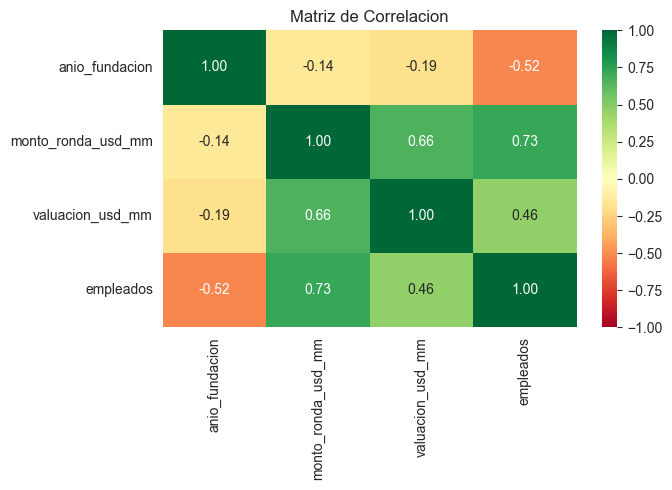

In [70]:
# Matriz de correlacion
cols = ['anio_fundacion', 'monto_ronda_usd_mm', 'valuacion_usd_mm', 'empleados']
corr = df_clean[cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('Matriz de Correlacion')
plt.tight_layout()
plt.show()

- `Verde` = correlación positiva (suben juntas)
- `Rojo` = correlación negativa (una sube, la otra baja)
- `Amarillo` = sin correlación

`monto_ronda` vs `empleados` (0.73) — la correlacion mas fuerte: las empresas que levantan mas capital tienden a tener mas empleados.

`monto_ronda` vs `valuacion` (0.66) — a mayor ronda, mayor valuacion. Tiene sentido — las rondas grandes validan valuaciones altas.

`anio_fundacion` vs `empleados` (-0.52) — las empresas mas antiguas tienen mas empleados. El signo negativo es porque anio_fundacion mas bajo = empresa mas vieja.

`anio_fundacion` vs `valuacion` (-0.19) y vs `monto_ronda` (-0.14) — correlacion debil, casi sin relacion.

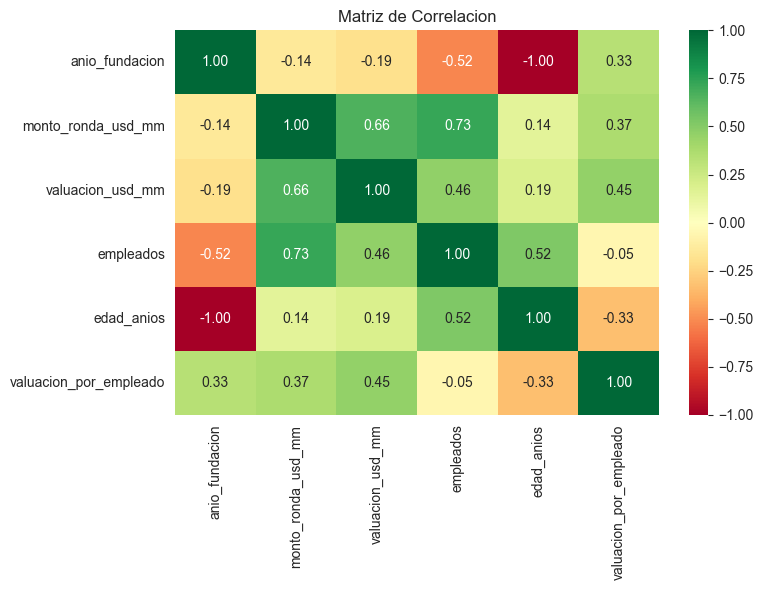

In [72]:
# Matriz de correlacion — todas las columnas numericas
corr = df_clean.select_dtypes(include='number').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('Matriz de Correlacion')
plt.tight_layout()
plt.show()